In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [143]:
h = 0.01
A = np.array( [[1, h], [0, 1]] )
B = np.array( [[0.5 * h * h] , [h]] )

# A B arrays are discrete dynamics of the system
# Used in order to get next state xn
# xn = Ax + Bu

In [88]:
n = 2 # number of states
m = 1 # number of controls
Tfinal = 5.0 # final time
N = int(Tfinal / h) + 1 # number of time steps, like discrete times cnt
thist = np.arange(0 , h * (N - 1) , step = h)

#x = np.array([[1.0] , [0]]) # Initial state
# Final x coodinate 
xn = np.array([[0.0] , [0]]) # 2x1 matr

print("Total steps: ", N)

Total steps:  51


In [151]:
# Introducing cost weights
Q = 1.0 * np.identity(2)
R = 1
Qn = 1.0 * np.identity(2)

print(Qn)


[[1. 0.]
 [0. 1.]]


In [116]:
def J(xhist, uhist):
    cost = (xhist[:,-1].T) @ Qn @ (xhist[:,-1])
    #print("J cost initial : ", cost)
    for k in range(1 , len(xhist)):
        xnew = xhist[ : , k ]
        cost += xnew.T @ Q @ xnew 
        cost += uhist[: , k].T * R @ uhist[: , k]
    
    return cost.flatten()

xtest = np.ones((2, 10)) * 1
utest = np.ones((2, 10))

print("J test")
print(J(xtest, utest))

def rollout(xhist, uhist):
    xnew = np.zeros_like(xhist)
    xnew[:,0] = xhist [:,0] 
    
    for k in range(1, xhist.shape[1]):
        xnew[:,k] = A @ xnew[:,k - 1] + (B.T @ uhist[:,k]) # I added T here, not sure
    return xnew

print("Rollout test")
print(rollout(xtest, utest))

J test
[4.2]
Rollout test
[[1.     1.205  1.4205 1.6465 1.883  2.13   2.3875 2.6555 2.934  3.223 ]
 [1.     1.105  1.21   1.315  1.42   1.525  1.63   1.735  1.84   1.945 ]]


In [7]:
uhist = np.zeros((2,N)) #
delta_u = np.ones((2,N))
lam_hist = np.zeros((2,N))
#initial guess
xhist = np.zeros((2 , N))

print(xhist)
# Have matrix of (N , 2)


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]]


In [154]:

uhist = np.zeros((2,N)) #
delta_u = np.ones((2,N))
lam_hist = np.zeros((2,N))
#initial guess
xhist = np.ones((2 , N)) * 100

print(xhist)
# Have matrix of (N , 2)

for t in range(500):
    
    #print("New Xhist", xhist)
    
    # Rollout
    xhist = rollout(xhist, uhist)
    # Find error
    t_error = J(xhist, uhist)
    
    print("ERROR on step : ", t, " : ", t_error)
    
    # Compute lambdas
    
    lam_hist[:, N - 1] = Q @ xn.flatten()
    
    for i in range(N - 2, 0, -1):
        lam_hist[:, i] = Q @ xhist[:, i] + A.T @ lam_hist[:, i + 1]
        
    #print("Lambdas : ",lam_hist)
    # Compute du 
    
    for i in range(0, N - 1):
        delta_u[:, i] = -(1/R) * B.T @ lam_hist[:, i + 1] 
            
            
    #print("Delta u: ", delta_u)
        
    p = 0.5
    
    # For every du, change u such it satisfy the condition
    for i in range(1, N - 1):
        #print("U : ", i)
        step = 1
        alpha = 0.5
        #uhist[:, i] -= delta_u[:, i] * step * alpha * h
        
        while alpha > 1e-4:
            #print("Changed from ", uhist[:, i], end=" to ")
            uhist[:, i] += delta_u[:, i] * step * alpha
            xhist = rollout(xhist, uhist)
            #print(uhist[:, i], "and new error became ", J(xhist, uhist))
            
            #print("Last xhist : ", xhist[:, -1])
            J_computed = J(xhist, uhist) 
            if J_computed < t_error: # + p * step * alpha * delta_u[: , i] @ delta_u[: , i] :
                t_error = J_computed
                break
            else:
                uhist[:, i] -= delta_u[:, i] * step * alpha
                alpha *= alpha
        """    
        step = -1
        alpha = 0.5
        while alpha > 1e-4:
            uhist[:, i] += delta_u[:, i] * step * alpha 
            xhist = rollout(xhist, uhist)
            if J(xhist, uhist) < t_error:#t_error + p * step * R * uhist[:, i] @ delta_u[: , i] :
                break
            else:
                uhist[:, i] -= delta_u[:, i] * step * alpha
                alpha *= alpha
        """
        
print("Lamhist", lam_hist)
print("Delta_u", delta_u)
print("Xhist", xhist)

[[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100.]
 [100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
  100. 100. 100. 100. 100. 100. 100. 100. 100.]]
ERROR on step :  0  :  [52701.]
ERROR on step :  1  :  [48680.97581581]
ERROR on step :  2  :  [45149.55142546]
ERROR on step :  3  :  [42039.3821304]
ERROR on step :  4  :  [39301.54459847]
ERROR on step :  5  :  [36892.71056695]
ERROR on step :  6  :  [34774.51251339]
ERROR on step :  7  :  [32912.98088697]
ERROR on step :  8  :  [31278.04485023]
ERROR on step :  9  :  [29843.08938521]
ERROR on step :  10  :  [28584.56242063]
ERROR on step :  11  :  [27481.62634948

ERROR on step :  190  :  [20267.55097285]
ERROR on step :  191  :  [20267.36867803]
ERROR on step :  192  :  [20267.17425899]
ERROR on step :  193  :  [20266.98759982]
ERROR on step :  194  :  [20266.79379779]
ERROR on step :  195  :  [20266.60748243]
ERROR on step :  196  :  [20266.41425253]
ERROR on step :  197  :  [20266.22843798]
ERROR on step :  198  :  [20266.03576096]
ERROR on step :  199  :  [20265.8506135]
ERROR on step :  200  :  [20265.65849126]
ERROR on step :  201  :  [20265.46670893]
ERROR on step :  202  :  [20265.28185675]
ERROR on step :  203  :  [20265.09063431]
ERROR on step :  204  :  [20264.90692626]
ERROR on step :  205  :  [20264.7163098]
ERROR on step :  206  :  [20264.52595575]
ERROR on step :  207  :  [20264.33580888]
ERROR on step :  208  :  [20264.15266212]
ERROR on step :  209  :  [20263.9631778]
ERROR on step :  210  :  [20263.77390677]
ERROR on step :  211  :  [20263.58483656]
ERROR on step :  212  :  [20263.40312472]
ERROR on step :  213  :  [20263.21490

ERROR on step :  394  :  [20234.71517097]
ERROR on step :  395  :  [20234.61534758]
ERROR on step :  396  :  [20234.51801407]
ERROR on step :  397  :  [20234.42062567]
ERROR on step :  398  :  [20234.32471768]
ERROR on step :  399  :  [20234.22965333]
ERROR on step :  400  :  [20234.13573389]
ERROR on step :  401  :  [20234.04294607]
ERROR on step :  402  :  [20233.95121278]
ERROR on step :  403  :  [20233.85940111]
ERROR on step :  404  :  [20233.76863872]
ERROR on step :  405  :  [20233.67807247]
ERROR on step :  406  :  [20233.58938329]
ERROR on step :  407  :  [20233.50056716]
ERROR on step :  408  :  [20233.4127705]
ERROR on step :  409  :  [20233.32597164]
ERROR on step :  410  :  [20233.24015585]
ERROR on step :  411  :  [20233.15531461]
ERROR on step :  412  :  [20233.07144486]
ERROR on step :  413  :  [20232.98753801]
ERROR on step :  414  :  [20232.90386917]
ERROR on step :  415  :  [20232.82190374]
ERROR on step :  416  :  [20232.74013955]
ERROR on step :  417  :  [20232.660

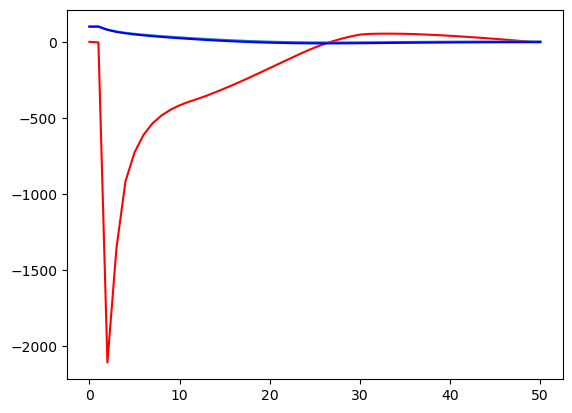

In [156]:
plt.plot(uhist[0, :], color = "RED")
plt.plot(xhist[0, :])
plt.plot(xhist[1, :], color = "BLUE")
